#                                                         Data Audition

## About Dataset


**About Dataset** <br>
This dataset contains 15,000 financial transaction records representing digital banking and electronic payment activities within the Indian financial ecosystem. The records include customer, banking, merchant, transaction, authentication, device, location, and behavioral information commonly associated with online financial services. The dataset is intended for research and development of intelligent financial fraud detection systems capable of distinguishing legitimate transactions from fraudulent activities.

The records represent various digital payment channels used across India, including Unified Payments Interface (UPI), Internet Banking, IMPS, NEFT, RTGS, debit cards, credit cards, and mobile wallet transactions. Banking information covers major Indian financial institutions, while merchant information spans multiple commercial sectors such as retail, healthcare, travel, education, telecommunications, utilities, and e-commerce.

Each transaction captures contextual information such as transaction value, payment method, customer profile, account details, authentication outcome, device characteristics, geographical location, transaction timing, and account activity indicators. These attributes collectively provide comprehensive information for analyzing transaction behavior and identifying suspicious financial activities.

The target column classifies every transaction into one of two categories: Legitimate or Fraudulent, making the dataset suitable for financial fraud detection, banking security analytics, digital payment risk assessment, transaction behavior analysis, and financial cybersecurity research.

**Column Description** <br>

transaction_id – Unique identifier assigned to each financial transaction.

customer_id – Unique identifier assigned to each customer.

bank_name – Name of the customer's banking institution.

account_type – Type of customer bank account.

merchant_name – Name of the merchant receiving the payment.

merchant_category – Business category of the merchant.

transaction_amount – Monetary value of the transaction in Indian Rupees (INR).

currency – Currency used for the transaction.

payment_method – Digital payment method used to complete the transaction.

upi_app – UPI application used to perform the payment.

transaction_type – Purpose or nature of the transaction.

transaction_hour – Hour of the day when the transaction occurred.

transaction_day – Day of the week on which the transaction occurred.

transaction_month – Month in which the transaction was performed.

customer_age – Age of the customer in years.

occupation – Occupation of the customer.

annual_income – Annual income of the customer in Indian Rupees.

state – Indian state where the customer is located.

city – City associated with the customer.

device_type – Type of device used for the transaction.

device_brand – Brand of the device used for the transaction.

mobile_network – Mobile network provider used during the transaction.

authentication_method – Authentication mechanism used for transaction approval.

authentication_status – Result of the authentication process.

login_attempts – Number of login attempts before the transaction.

failed_login_count – Number of unsuccessful login attempts.

previous_transactions – Number of previous transactions completed by the customer.

average_transaction_amount – Average amount of previous customer transactions.

account_balance – Available account balance before the transaction.

beneficiary_age_days – Number of days since the beneficiary account was created.

beneficiary_bank – Banking institution of the beneficiary.

merchant_risk_score – Risk score associated with the merchant.

device_trust_score – Trust score assigned to the customer's device.

ip_risk_score – Risk score associated with the transaction IP address.

transaction_distance_km – Estimated distance between customer and transaction location.

location_match – Indicates whether the transaction location matches the customer's usual location.

new_device – Indicates whether the transaction originated from a newly used device.

international_transaction – Indicates whether the transaction involved an international payment.

weekend_transaction – Indicates whether the transaction occurred during the weekend.

high_value_transaction – Indicates whether the transaction exceeded the high-value threshold.

transaction_duration_sec – Time required to complete the transaction in seconds.

fraud_label – Transaction category indicating Legitimate or Fraudulent.

## Importing Packages

In [56]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [57]:
pd.options.display.min_rows = 45
%matplotlib inline


## Reading Data

In [2]:
data = pd.read_csv('../data/Fraud_Detection_Dataset.csv')
data.head()

,transaction_id,customer_id,bank_name,account_type,merchant_name,merchant_category,transaction_amount,currency,payment_method,upi_app,...,device_trust_score,ip_risk_score,transaction_distance_km,location_match,new_device,international_transaction,weekend_transaction,high_value_transaction,transaction_duration_sec,fraud_label
0,TXN1000000,CUST46048,Axis Bank,Current,Bharat Petroleum,Pharmacy,3998.30,INR,IMPS,Amazon Pay,...,89.29,60.11,1770.18,Yes,No,No,No,No,5.23,Fraudulent
1,TXN1000001,CUST65392,Canara Bank,Salary,Bharat Petroleum,Restaurant,2706.99,INR,Credit Card,PhonePe,...,51.99,4.67,2434.39,Yes,Yes,No,No,No,156.70,Legitimate
2,TXN1000002,CUST19116,State Bank of India,Current,Swiggy,Pharmacy,3196.37,INR,RTGS,Navi,...,44.37,9.77,1710.58,Yes,Yes,No,Yes,No,56.14,Legitimate
3,TXN1000003,CUST70589,Union Bank of India,Salary,BookMyShow,Restaurant,2090.97,INR,Credit Card,Navi,...,22.51,84.23,1124.39,Yes,No,No,Yes,No,31.11,Legitimate
4,TXN1000004,CUST28301,Axis Bank,Salary,Jio,Telecom,2747.35,INR,Net Banking,Paytm,...,63.42,14.09,2005.49,Yes,No,No,No,No,91.58,Legitimate


In [19]:
# shape
data.shape

(15000, 42)

In [11]:
def audit_dataframe(df):
    result = pd.DataFrame(df.isnull().sum(), columns=['Missing Values'])
    result['Data Type'] = df.dtypes
    result['Unique Values'] = df.nunique()
    result['Percentage Missing'] = (result['Missing Values'] / len(df)) * 100
    return result

data_audit_results = audit_dataframe(data)
display(data_audit_results)


,Missing Values,Data Type,Unique Values,Percentage Missing
transaction_id,0,str,15000,0.0
customer_id,0,str,13826,0.0
bank_name,0,str,10,0.0
account_type,0,str,4,0.0
merchant_name,0,str,18,0.0
merchant_category,0,str,11,0.0
transaction_amount,0,float64,14815,0.0
currency,0,str,1,0.0
payment_method,0,str,8,0.0
upi_app,0,str,7,0.0


In [13]:
# Checking for duplicates in the dataset
data.duplicated().sum() 

np.int64(0)

In [20]:
# Fields classification

categorical_vars = [
    "bank_name",
    "account_type",
    "merchant_name",
    "merchant_category",
    "currency",
    "payment_method",
    "upi_app",
    "transaction_type",
    "transaction_day",
    "transaction_month",
    "occupation",
    "device_type",
    "device_brand",
    "mobile_network",
    "authentication_method",
    "authentication_status",
    "beneficiary_bank",
    "location_match",
    "new_device",
    "international_transaction",
    "weekend_transaction",
    "high_value_transaction"
]

numerical_vars = [
    "transaction_amount",
    "transaction_hour",
    "customer_age",
    "annual_income",
    "login_attempts",
    "failed_login_count",
    "previous_transactions",
    "average_transaction_amount",
    "account_balance",
    "beneficiary_age_days",
    "merchant_risk_score",
    "device_trust_score",
    "ip_risk_score",
    "transaction_distance_km",
    "transaction_duration_sec"
]

geographical_vars = [
    "state",
    "city"
]


target_var = [
    "fraud_label"
]


### Categorical data

In [21]:
data[categorical_vars]

,bank_name,account_type,merchant_name,merchant_category,currency,payment_method,upi_app,transaction_type,transaction_day,transaction_month,...,device_brand,mobile_network,authentication_method,authentication_status,beneficiary_bank,location_match,new_device,international_transaction,weekend_transaction,high_value_transaction
0,Axis Bank,Current,Bharat Petroleum,Pharmacy,INR,IMPS,Amazon Pay,Recharge,Monday,February,...,Vivo,BSNL,UPI PIN,Success,State Bank of India,Yes,No,No,No,No
1,Canara Bank,Salary,Bharat Petroleum,Restaurant,INR,Credit Card,PhonePe,Purchase,Monday,June,...,Motorola,Jio,MPIN,Success,Kotak Mahindra Bank,Yes,Yes,No,No,No
2,State Bank of India,Current,Swiggy,Pharmacy,INR,RTGS,Navi,Purchase,Wednesday,August,...,Realme,Airtel,Biometric,Success,ICICI Bank,Yes,Yes,No,Yes,No
3,Union Bank of India,Salary,BookMyShow,Restaurant,INR,Credit Card,Navi,Purchase,Sunday,January,...,Apple,Airtel,Biometric,Success,Bank of Baroda,Yes,No,No,Yes,No
4,Axis Bank,Salary,Jio,Telecom,INR,Net Banking,Paytm,Bill Payment,Friday,August,...,Xiaomi,BSNL,OTP,Success,Indian Bank,Yes,No,No,No,No
5,HDFC Bank,Salary,Zomato,Pharmacy,INR,Debit Card,BHIM,Bill Payment,Monday,December,...,Apple,Vi,UPI PIN,Success,Indian Bank,Yes,Yes,No,No,No
6,Bank of Baroda,Savings,Indian Oil,Hospital,INR,Debit Card,Google Pay,Purchase,Friday,February,...,Xiaomi,BSNL,UPI PIN,Success,Indian Bank,Yes,Yes,No,Yes,No
7,Union Bank of India,Salary,BSNL,Utility Bill,INR,Mobile Wallet,PhonePe,Bill Payment,Monday,June,...,Apple,Jio,UPI PIN,Success,HDFC Bank,Yes,No,No,No,No
8,Bank of Baroda,Current,BookMyShow,Fuel Station,INR,Mobile Wallet,Google Pay,Recharge,Tuesday,February,...,OnePlus,BSNL,OTP,Success,Canara Bank,Yes,No,Yes,No,No
9,Axis Bank,Business,Bharat Petroleum,Education,INR,NEFT,Paytm,Recharge,Sunday,February,...,Apple,Airtel,UPI PIN,Success,Union Bank of India,Yes,No,No,Yes,No


In [38]:
data[categorical_vars].nunique()

bank_name                    10
account_type                  4
merchant_name                18
merchant_category            11
currency                      1
payment_method                8
upi_app                       7
transaction_type              6
transaction_day               7
transaction_month            12
occupation                    8
device_type                   4
device_brand                  8
mobile_network                4
authentication_method         4
authentication_status         2
beneficiary_bank             10
location_match                2
new_device                    2
international_transaction     2
weekend_transaction           2
high_value_transaction        1
dtype: int64

In [66]:
data['authentication_status'].compare(data['fraud_label'])

,self,other
0,Success,Fraudulent
1,Success,Legitimate
2,Success,Legitimate
3,Success,Legitimate
4,Success,Legitimate
5,Success,Legitimate
6,Success,Legitimate
7,Success,Legitimate
8,Success,Legitimate
9,Success,Legitimate


In [ ]:
# Compare authentication status with fraud labels
status_fraud_table = pd.crosstab(
    data["authentication_status"],
    data["fraud_label"],
    margins=True
)

display(status_fraud_table)

# Fraud rate for each authentication status
fraud_rate_by_status = pd.crosstab(
    data["authentication_status"],
    data["fraud_label"],
    normalize="index"
).mul(100).round(2)

display(fraud_rate_by_status)

### Numerical Data

In [28]:
data[numerical_vars]

,transaction_amount,transaction_hour,customer_age,annual_income,login_attempts,failed_login_count,previous_transactions,average_transaction_amount,account_balance,beneficiary_age_days,merchant_risk_score,device_trust_score,ip_risk_score,transaction_distance_km,transaction_duration_sec
0,3998.30,1,31,2269613,4,2,103,4313.87,125217.62,3561,10.52,89.29,60.11,1770.18,5.23
1,2706.99,12,72,1259480,1,2,106,2948.79,18938.41,2575,54.85,51.99,4.67,2434.39,156.70
2,3196.37,12,58,832220,6,0,77,2084.17,772522.81,2601,81.80,44.37,9.77,1710.58,56.14
3,2090.97,7,69,1832607,2,3,50,2518.13,166749.36,3624,58.93,22.51,84.23,1124.39,31.11
4,2747.35,4,23,609901,4,3,76,2244.80,285724.28,1918,31.69,63.42,14.09,2005.49,91.58
5,2428.01,14,74,2249610,2,2,97,2838.52,484965.00,662,93.00,72.09,91.50,2125.10,100.93
6,4828.53,7,23,440298,3,3,27,3359.09,608747.65,3805,58.32,81.68,49.38,1306.83,269.25
7,3554.84,7,19,1073658,1,0,110,4110.86,483731.69,1354,56.28,36.24,94.29,1497.16,191.85
8,2069.63,13,24,1636031,6,0,7,2134.77,716924.99,1650,35.21,28.80,22.79,1067.77,162.56
9,4036.55,7,46,362182,4,3,61,3291.93,135048.69,876,25.78,64.65,40.38,162.23,93.76


In [29]:
data[numerical_vars].describe()

,transaction_amount,transaction_hour,customer_age,annual_income,login_attempts,failed_login_count,previous_transactions,average_transaction_amount,account_balance,beneficiary_age_days,merchant_risk_score,device_trust_score,ip_risk_score,transaction_distance_km,transaction_duration_sec
count,15000.000000,15000.000000,15000.000000,1.500000e+04,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,3364.705089,11.549400,49.045400,1.318954e+06,3.478400,1.492133,60.259467,3354.375151,402655.639635,1992.526333,52.822341,60.160885,49.923953,1249.877623,152.635117
std,2006.690292,6.944051,18.168486,6.793796e+05,1.695364,1.121497,34.843733,2189.479437,230213.106170,1151.294699,27.463069,23.049266,28.707196,721.894812,84.900839
min,70.870000,0.000000,18.000000,1.501180e+05,1.000000,0.000000,0.000000,54.800000,505.250000,1.000000,5.000000,20.000000,0.000000,0.040000,5.030000
25%,1880.562500,5.000000,33.000000,7.297760e+05,2.000000,0.000000,31.000000,1772.852500,203884.177500,1004.000000,29.190000,40.040000,25.120000,620.897500,79.260000
50%,2964.055000,12.000000,49.000000,1.316374e+06,3.000000,1.000000,60.000000,2853.885000,406364.225000,1975.000000,52.895000,60.595000,49.515000,1251.815000,152.315000
75%,4414.120000,18.000000,65.000000,1.905082e+06,5.000000,2.000000,90.000000,4369.220000,599423.600000,2983.250000,76.630000,80.100000,74.610000,1876.727500,225.905000
max,15646.070000,23.000000,80.000000,2.499566e+06,6.000000,3.000000,120.000000,18091.760000,799962.120000,3999.000000,100.000000,99.990000,99.980000,2499.650000,299.980000


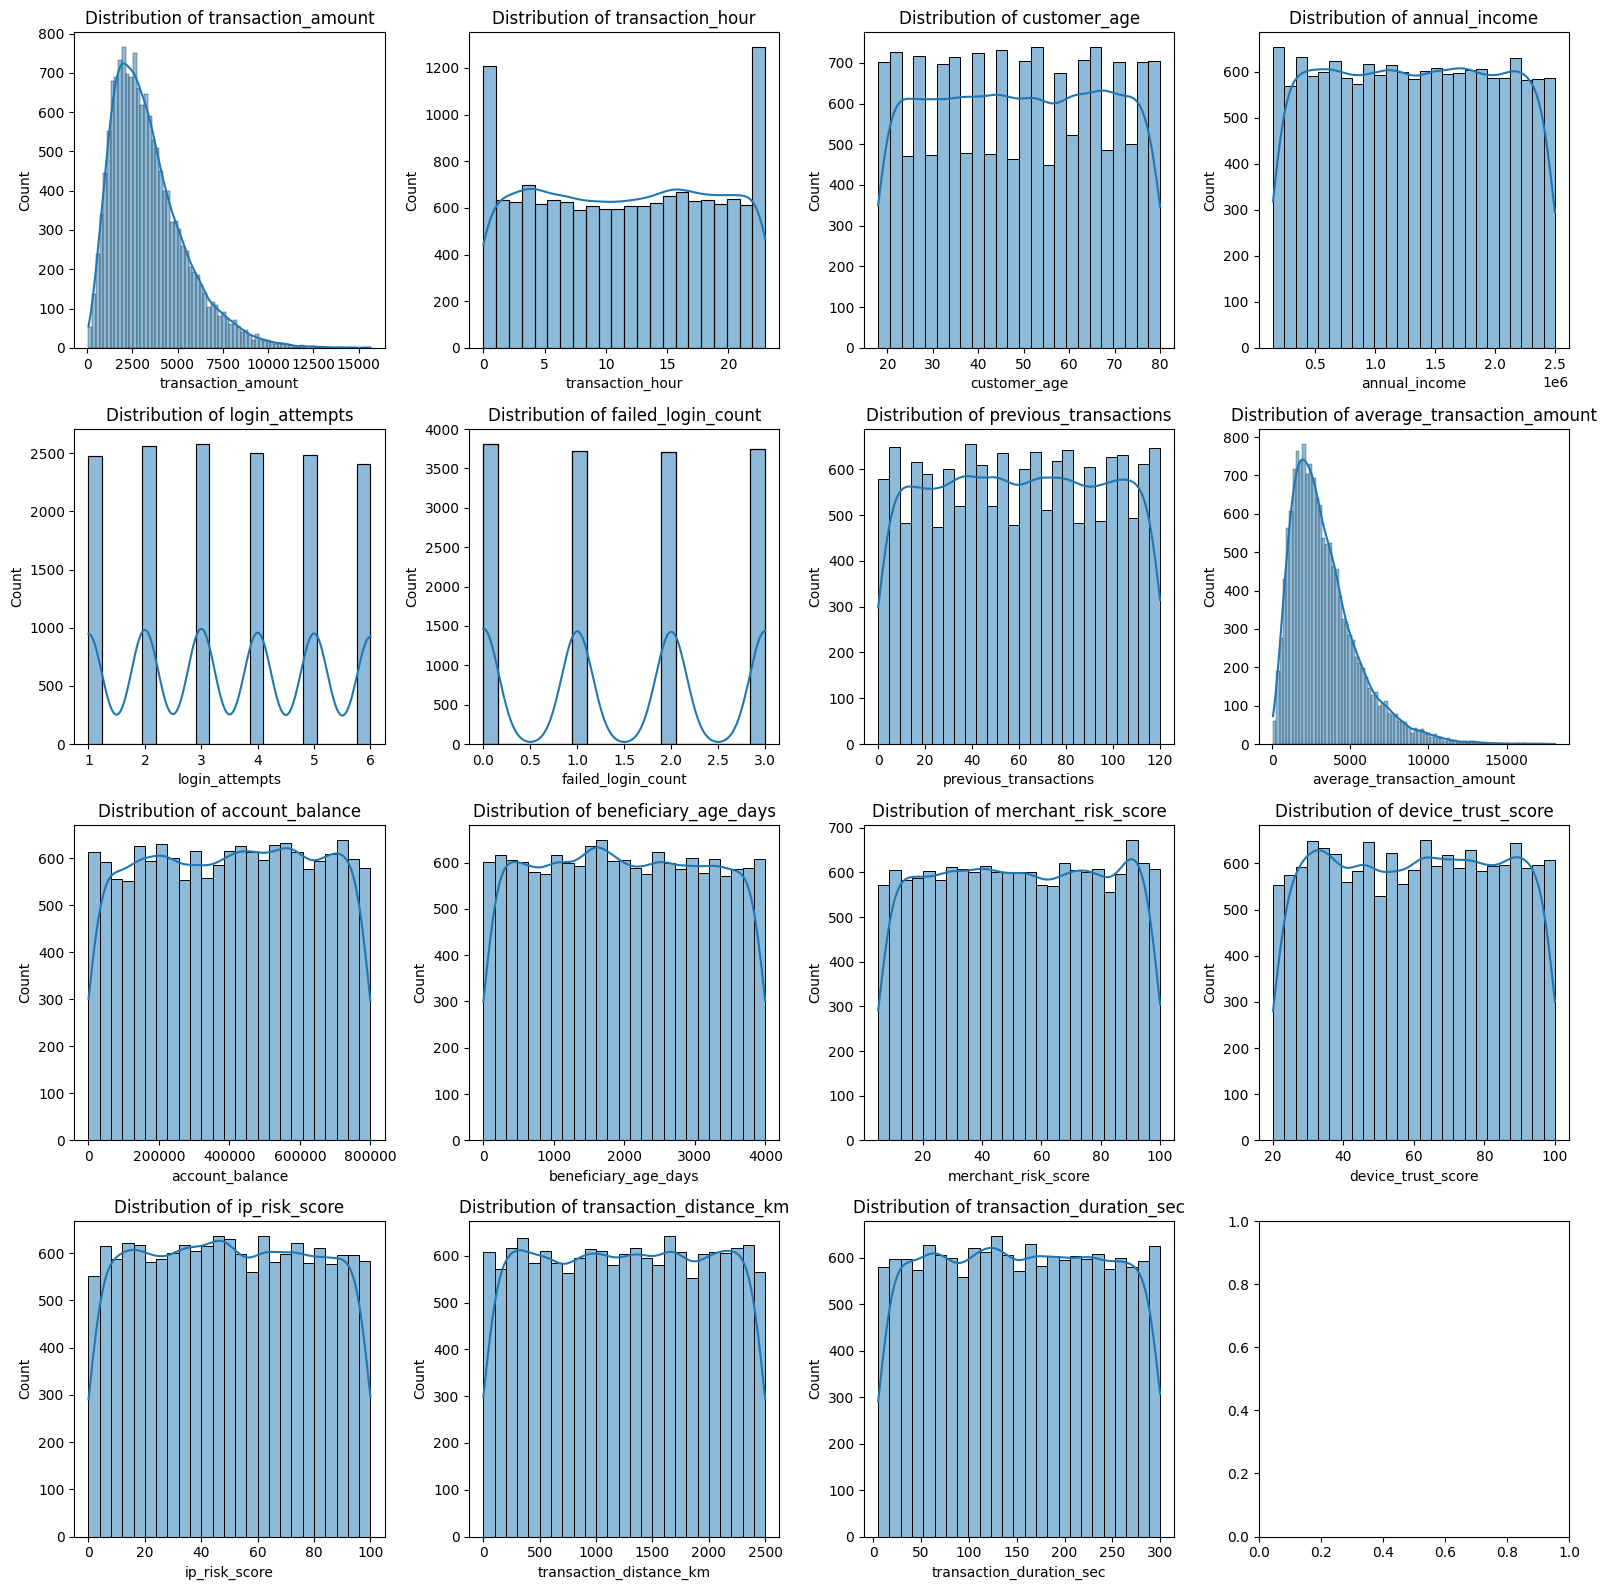

In [62]:
# Plot a distribution of the numerical variables
fig, axes = plt.subplots(4, 4, figsize=(16, 16))
axes = axes.flatten()  # Flatten to easily iterate
    
    # Loop through columns and plot
for i, col in enumerate(numerical_vars):
     sns.histplot(data[col], kde=True, ax=axes[i])
     axes[i].set_title(f"Distribution of {col}")
plt.tight_layout()
plt.show()

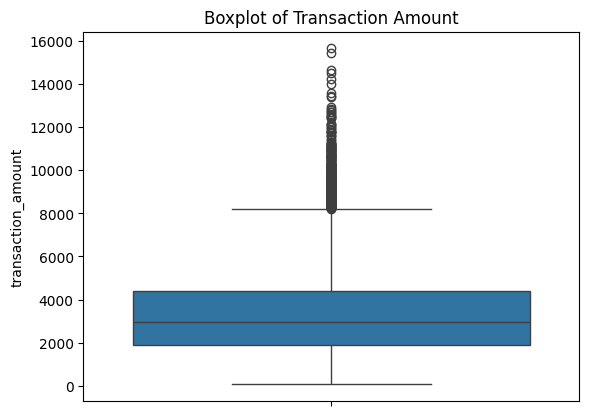

In [64]:
sns.boxplot(data['transaction_amount'])
plt.title("Boxplot of Transaction Amount")
plt.show()

### Target Field

In [51]:
target_df = data[target_var].value_counts().to_frame()
target_df['percentage'] = ((target_df['count'] / len(data)) * 100).round(2)
target_df

,count,percentage
fraud_label,,
Legitimate,13804,92.03
Fraudulent,1196,7.97


## Data Report

* There is no Missing Value
* `high_value_transaction` Field is useless, has only a single value
* `currency` Field is the same
* The Legit transactions are 92.03% whereas the Fraud transactions are 7.97%. The dataset is highly imbalanced